In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
df = pd.read_csv("D:/ecommerce-customer-intelligence/data/processed/ecommerce_clean.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']


#snapshot date
snapshot_date = df['InvoiceDate'].max()+pd.Timedelta(days=1)


In [10]:
rfm = (
    df.groupby('CustomerID')
      .agg(
          Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
          Frequency=('InvoiceNo', 'nunique'),
          Monetary=('TotalPrice', 'sum')
      )
      .reset_index()
)

print(f'RFM Table shape = {rfm.shape}')
print(rfm.describe().round(2))

RFM Table shape = (4338, 4)
       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2054.27
std       1721.81   100.01       7.70    8989.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     307.41
50%      15299.50    51.00       2.00     674.48
75%      16778.75   142.00       5.00    1661.74
max      18287.00   374.00     209.00  280206.02


In [19]:

# RFM Scoring

rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)


# Composite RFM Score (string concatenation)
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# Weighted RFM score
rfm['RFM_Total'] = (
    rfm['R_Score'] * 0.4 +
    rfm['F_Score'] * 0.35 +
    rfm['M_Score'] * 0.25
)

                

In [24]:
#Segmenting Customers 

def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 3 and f == 1:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
print(rfm['Segment'].value_counts())
rfm.to_csv(
    "D:/ecommerce-customer-intelligence/data/processed/rfm_segments.csv",
    index=False
)
print("✅ RFM data saved!")

Segment
Loyal Customers        998
Champions              962
Cant Lose Them         691
At Risk                454
Lost                   453
Recent Customers       319
Hibernating            235
Promising              164
Potential Loyalists     62
Name: count, dtype: int64
✅ RFM data saved!


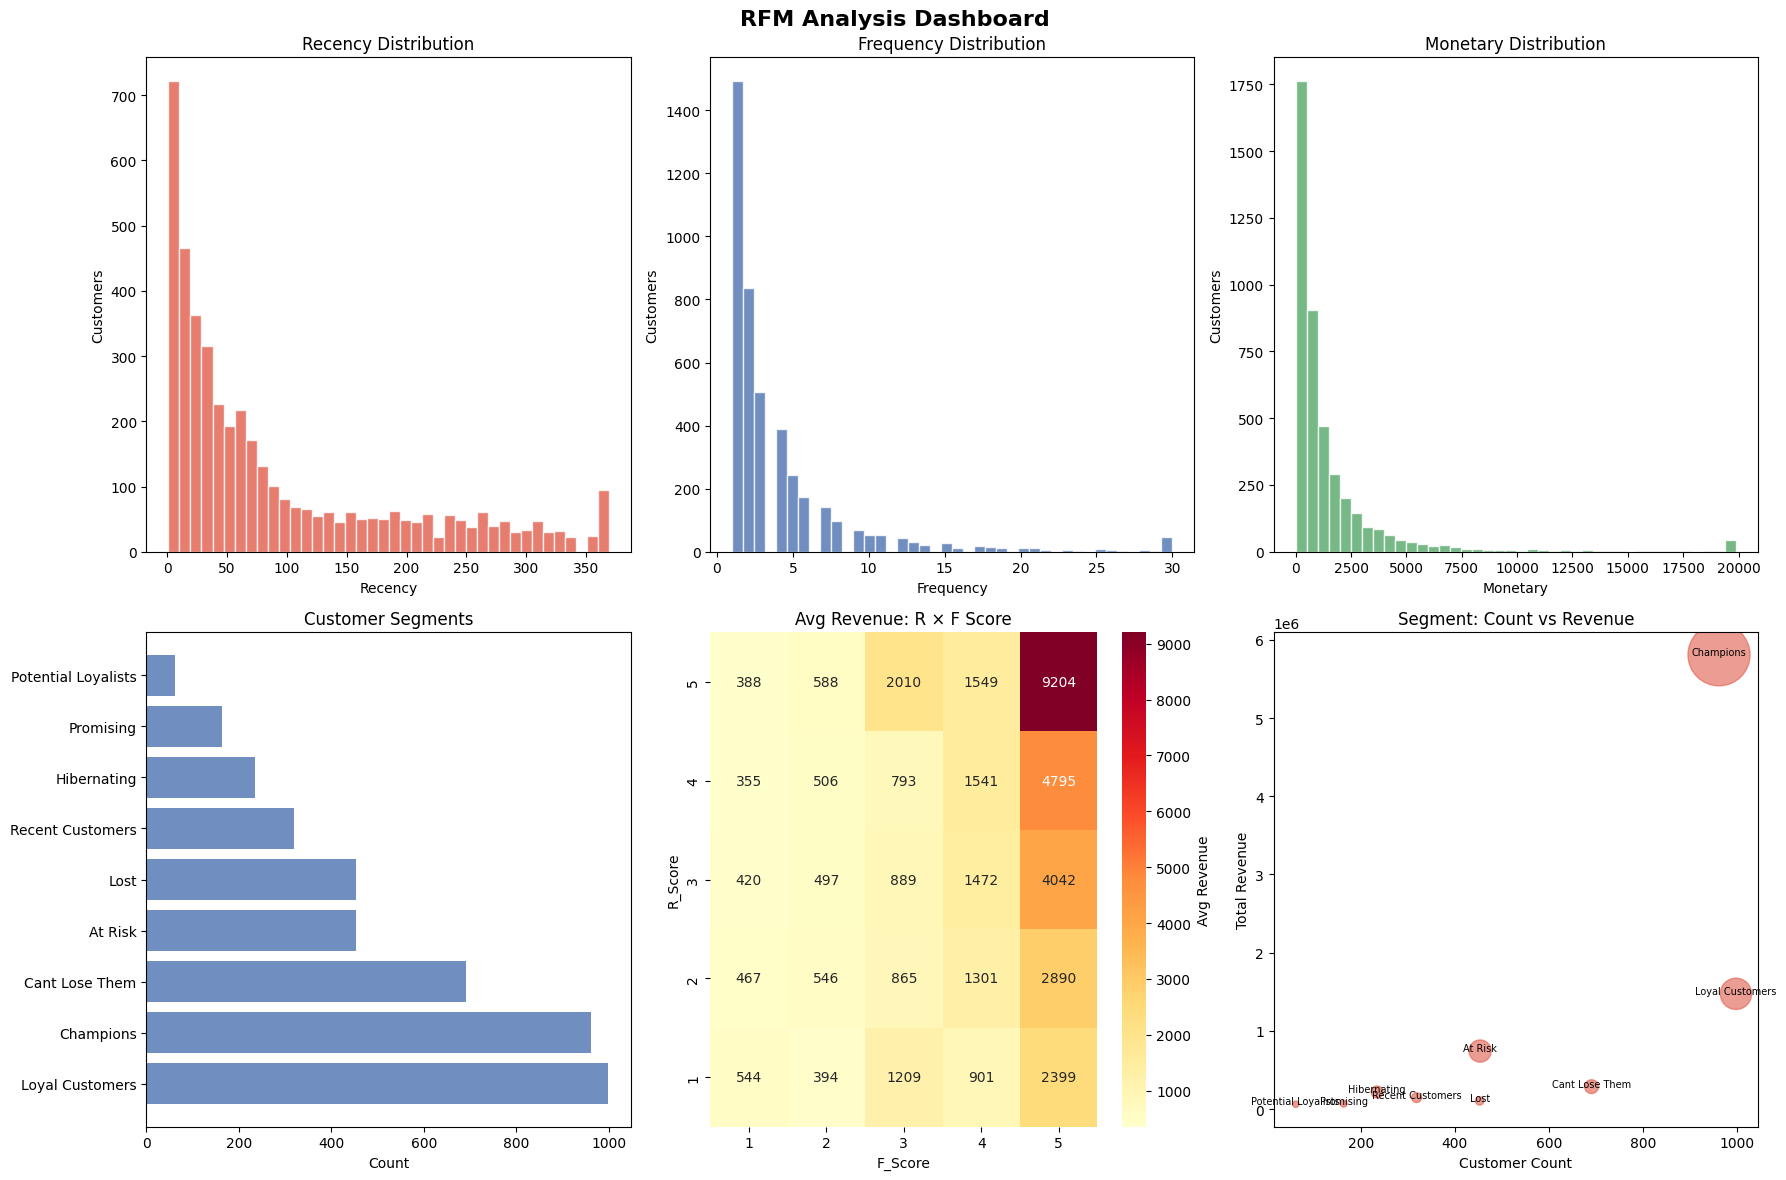

In [13]:
# ── 6. Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('RFM Analysis Dashboard', fontsize=16, fontweight='bold')

# (a) R/F/M raw distributions
for ax, col, color in zip(axes[0],
                           ['Recency', 'Frequency', 'Monetary'],
                           ['#E05C4B', '#4C72B0', '#55A868']):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))  # cap outliers for plot
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Customers')

# (b) Segment bar chart
seg_counts = rfm['Segment'].value_counts()
axes[1, 0].barh(seg_counts.index, seg_counts.values, color='#4C72B0', alpha=0.8)
axes[1, 0].set_title('Customer Segments')
axes[1, 0].set_xlabel('Count')

# (c) RFM heatmap — avg Monetary by R & F score
pivot = rfm.pivot_table(values='Monetary', index='R_Score',
                         columns='F_Score', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[1, 1], cbar_kws={'label': 'Avg Revenue'})
axes[1, 1].set_title('Avg Revenue: R × F Score')
axes[1, 1].invert_yaxis()

# (d) Segment revenue treemap via scatter 
seg_stats = rfm.groupby('Segment').agg(
    Count=('CustomerID', 'count'),
    Revenue=('Monetary', 'sum')
).reset_index()
axes[1, 2].scatter(seg_stats['Count'], seg_stats['Revenue'],
                   s=seg_stats['Revenue']/seg_stats['Revenue'].max()*2000,
                   alpha=0.6, color='#E05C4B')
for _, row in seg_stats.iterrows():
    axes[1, 2].annotate(row['Segment'], (row['Count'], row['Revenue']),
                        fontsize=7, ha='center')
axes[1, 2].set_xlabel('Customer Count')
axes[1, 2].set_ylabel('Total Revenue')
axes[1, 2].set_title('Segment: Count vs Revenue')

plt.tight_layout()
plt.savefig('D:/ecommerce-customer-intelligence/reports/rfm_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()


## RFM Segmentation Results

- Total Customers: 4,338
- 45.2% are Champions or Loyal Customers — strong base
- 36.8% are At Risk, Cant Lose Them, or Lost — churn risk
- Cant Lose Them segment needs immediate marketing attention

In [26]:
# Final RFM Summary
print(rfm.columns.tolist())
print("="*50)
print("RFM SUMMARY")
print("="*50)
print(f"Total Customers: {len(rfm)}")
print(f"\nSegment Distribution:")
print(rfm['Segment'].value_counts())
print(f"\nRFM Stats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment']
RFM SUMMARY
Total Customers: 4338

Segment Distribution:
Segment
Loyal Customers        998
Champions              962
Cant Lose Them         691
At Risk                454
Lost                   453
Recent Customers       319
Hibernating            235
Promising              164
Potential Loyalists     62
Name: count, dtype: int64

RFM Stats:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


In [27]:
# Save RFM table
rfm.to_csv(
    "D:/ecommerce-customer-intelligence/data/processed/rfm_segments.csv",
    index=False
)
print("✅ RFM data saved!")
print(f"Shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")

✅ RFM data saved!
Shape: (4338, 10)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment']
